import needed libraries

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy

read in one of the DepMap datasets (PRISM)

In [109]:
screenData = pd.read_csv('Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv')
drugMetadata = pd.read_csv('Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv')

take a smaller slice of the data for testing purposes (transpose for correlation steps later)


In [110]:
screenDataSlice = screenData.iloc[0:1000, 0:300]
screenDataSlice = screenDataSlice.set_index('Unnamed: 0')
screenDataSlice = screenDataSlice.T

plot an exploratory heatmap 

<Axes: xlabel='Unnamed: 0'>

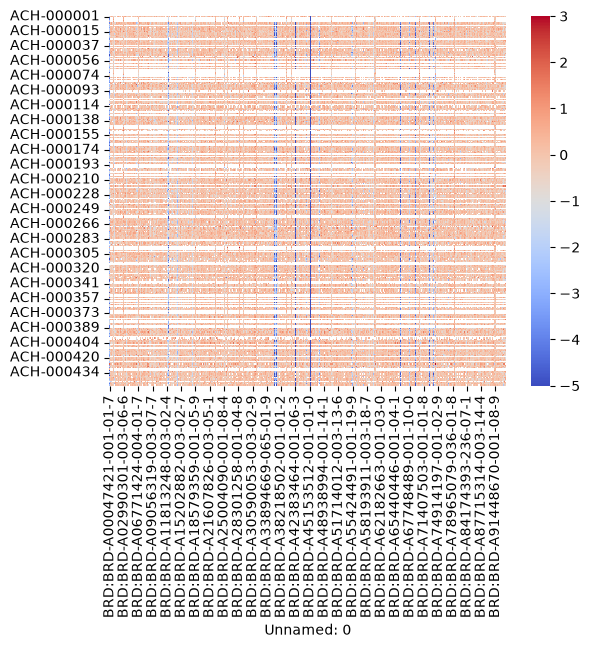

In [111]:
sea.heatmap(screenDataSlice, annot=False, vmin=-5, vmax=3, cmap='coolwarm')

Here, 'ACH' identifiers are cell lines, and 'BRD' identifiers are drugs. So, most of these cells lines have been treated with most of the drugs, but a subset of cell lines have only been treated with a subset of drugs (not really a problem for drug-drug correlations, I think). You can also sort of tell that many drug effects are near zero (i.e. no effect of that drug on that cell line), which makes sense. A few drugs have very strong effects in the majority of cell lines. 

Let's make a drug-drug correlation matrix of this data and plot with a heatmap (defaults to Pearson correlations). 

<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

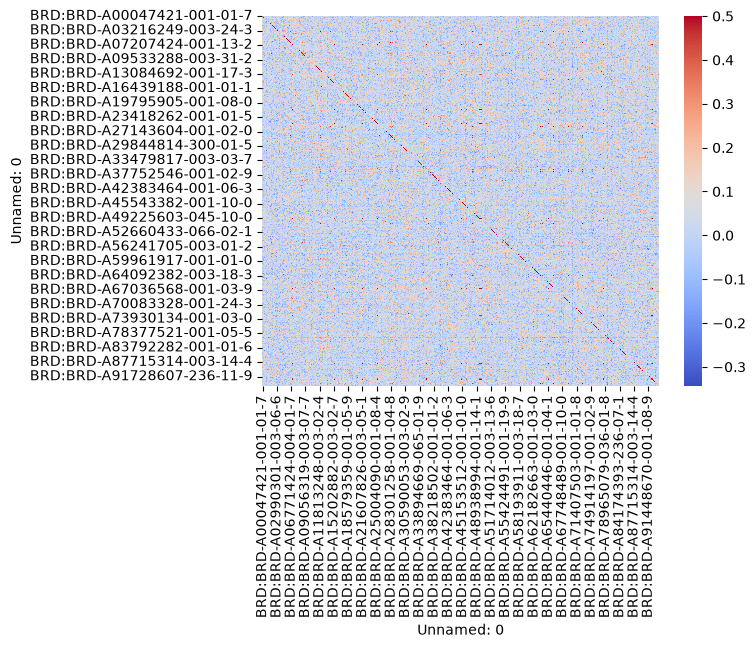

In [114]:
corr_matrix = screenDataSlice.corr(numeric_only=True)
sea.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmax=0.5)

It's difficult to see, but this indicates that the majority of drugs pairs do not show strong correlation- another good sign. We will examine this in more detail in a bit. 

Let's repeat the correlation analysis for the full dataset this time:

In [115]:
screenData = screenData.set_index('Unnamed: 0')
screenData = screenData.T

corr_matrix_full = screenData.corr(numeric_only=True)

Instead of plotting the correlation matrix as a heatmap, let's look at the distribution of correlations: 

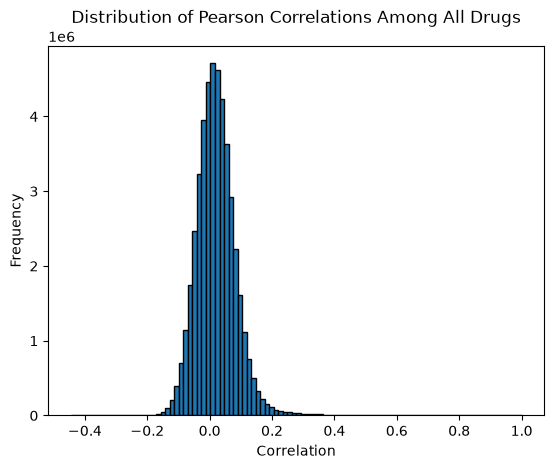

In [116]:
plt.hist(corr_matrix_full.values.flatten(), bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('linear')

It's cool to see that the distribution looks pretty Gaussian, and is pretty much centered around 0 (that is, most drug pairs show no strong correlation, as we'd expect). However, if my method is to work, there need to be *some* drug pairs that do correlate, so I suspect that this distribution has a tail. Plot on a log scale to see if this is true: 

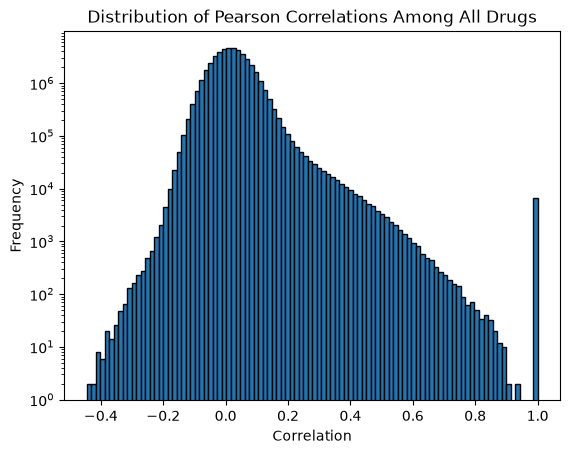

In [117]:
plt.hist(corr_matrix_full.values.flatten(), bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('log')

Indeed, there are some drug pairs that show a range of 'stronger' correlation values. I'm a little confused why there are ~10^4 drug pairs with perfect correlation (when there should be 6790, the number of drugs in the correlation matrix), but maybe this is a trick of the axes... this also shows that there isn't really a natural 'shoulder' or cutoff value to use as a threshold for 'meaningful' correlation. 

To facilitate isolating drug pairs with specific correlations, let's reshape the correlation matrix: 

In [118]:
corr_matrix_tofilter = corr_matrix_full
corr_matrix_tofilter['Drug'] = corr_matrix_tofilter.index
col_to_move = corr_matrix_tofilter.pop('Drug')
corr_matrix_tofilter.insert(0, 'Drug', col_to_move)
corr_matrix_tofilter_long = pd.melt(corr_matrix_tofilter, id_vars ='Drug', var_name='Partner', value_name='Pearson')

Plot histogram of 'Pearson' column as a sanity check: 

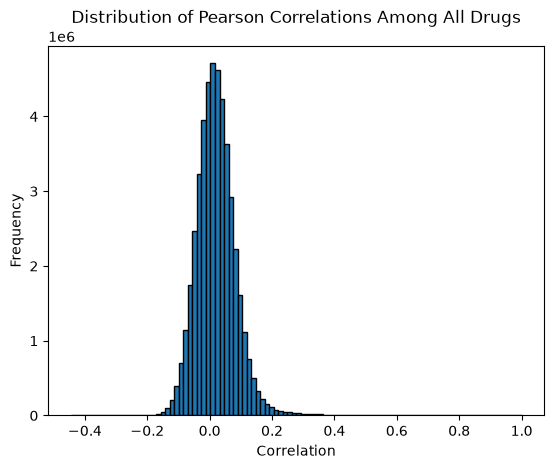

In [119]:
plt.hist(corr_matrix_tofilter_long['Pearson'], bins=100, edgecolor='black')
plt.title('Distribution of Pearson Correlations Among All Drugs')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.yscale('linear')

Sort this new correlation dataframe by correlationt to find the top correlating drug pairs (and filter out the pairs with perfect correlation): 

In [120]:
corr_matrix_tofilter_descending = corr_matrix_tofilter_long.sort_values(by='Pearson', ascending=False)
corr_matrix_tofilter_descending = corr_matrix_tofilter_descending[corr_matrix_tofilter_long['Pearson'] != 1.0]

<positron-console-cell-120>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


In [121]:
corr_matrix_tofilter_descending.head(10)

,Drug,Partner,Pearson
1290954,BRD:BRD-A78210457-001-01-5,BRD:BRD-A16035238-001-01-7,0.929351
5798850,BRD:BRD-A16035238-001-01-7,BRD:BRD-A78210457-001-01-5,0.929351
36114141,BRD:BRD-K61397605-001-03-4,BRD:BRD-K69650333-003-14-0,0.907663
33418908,BRD:BRD-K69650333-003-14-0,BRD:BRD-K61397605-001-03-4,0.907663
9221010,BRD:BRD-A16035238-001-01-7,BRD:BRD-K00003406-001-01-9,0.898368
1291458,BRD:BRD-K00003406-001-01-9,BRD:BRD-A16035238-001-01-7,0.898368
33418046,BRD:BRD-K51911221-001-01-2,BRD:BRD-K61397605-001-03-4,0.893951
30261161,BRD:BRD-K61397605-001-03-4,BRD:BRD-K51911221-001-01-2,0.893951
21820344,BRD:BRD-K44432556-001-05-5,BRD:BRD-K26122255-001-01-7,0.892588
27665673,BRD:BRD-K26122255-001-01-7,BRD:BRD-K44432556-001-05-5,0.892588


This is cool- also reveals that all of the correlations are duplicated (drug A corr with drug B vs drug B corr with drug A) which is a small issue to fix later. Let's plot the top correlated drug pair and find the drug identities using the drug screen metadata dataframe: 

In [122]:
drug_A = corr_matrix_tofilter_descending.iat[0,0]
drug_B = corr_matrix_tofilter_descending.iat[0,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

<Axes: xlabel='BRD:BRD-A78210457-001-01-5', ylabel='BRD:BRD-A16035238-001-01-7'>

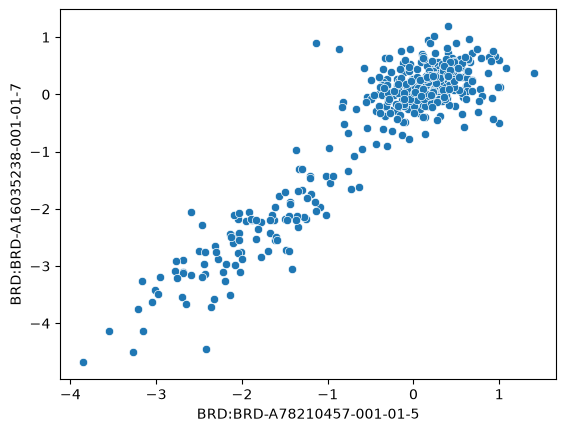

In [123]:
sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

This is really cool in that is shows a cluster of cell lines around (0,0), indicating that these cells don't really care about either drug. But, cell lines which care about one drug (i.e. have a non-zero effect of that drug) also tend to care about the other drug to a similar extent. 

In [124]:
drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
4705,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A16035238-001-01-7,SAR405838,SAR405838
4754,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A78210457-001-01-5,RG7112,RG7112


What do you know, these are two different drugs with the same target (MDM2), as we would predict! Let's try the same thing for a few other drug pairs:

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
2908,REP.PRIMARY,2.5,"MDM2, TP53",MDM INHIBITOR,BRD:BRD-K62627508-001-01-5,IDASANUTLIN,IDASANUTLIN
4705,REP.PRIMARY,2.5,MDM2,MDM INHIBITOR,BRD:BRD-A16035238-001-01-7,SAR405838,SAR405838


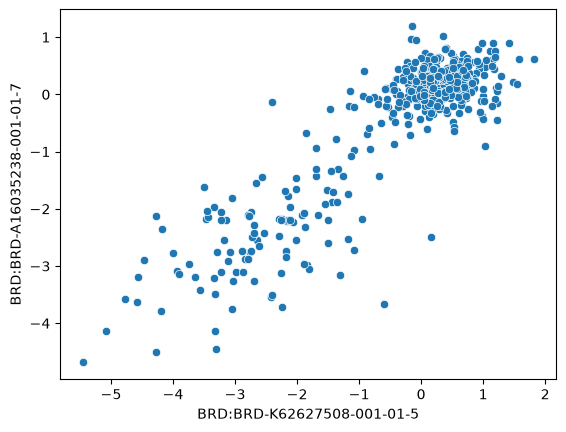

In [17]:
drug_A = corr_matrix_tofilter_descending.iat[10,0]
drug_B = corr_matrix_tofilter_descending.iat[10,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
1208,REP.PRIMARY,2.5,"MAP2K1, MAP2K2",MEK INHIBITOR,BRD:BRD-K12343256-001-08-9,TRAMETINIB,TRAMETINIB
3781,REP.PRIMARY,2.5,"MAP2K1, MAP2K2",MEK INHIBITOR,BRD:BRD-K89014967-001-04-3,AS-703026,AS-703026


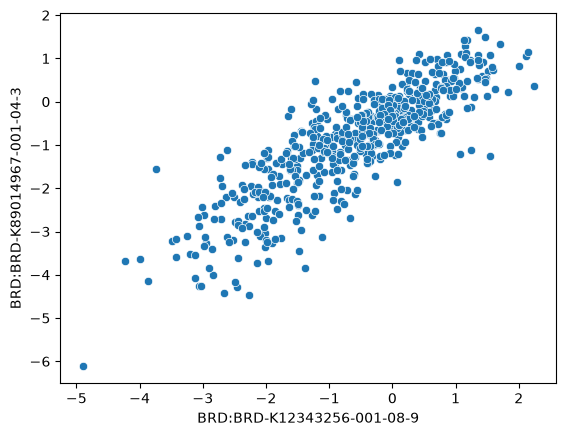

In [18]:
drug_A = corr_matrix_tofilter_descending.iat[50,0]
drug_B = corr_matrix_tofilter_descending.iat[50,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
5204,REP.PRIMARY,2.5,"BRAF, MAP2K1, MAP2K2, RAF1","MEK INHIBITOR, RAF INHIBITOR",BRD:BRD-K82804538-001-01-0,RO-5126766,RO-5126766
5259,REP.PRIMARY,2.5,MAPK1,MAP KINASE INHIBITOR,BRD:BRD-K93725829-001-03-8,VX-11E,VX-11E


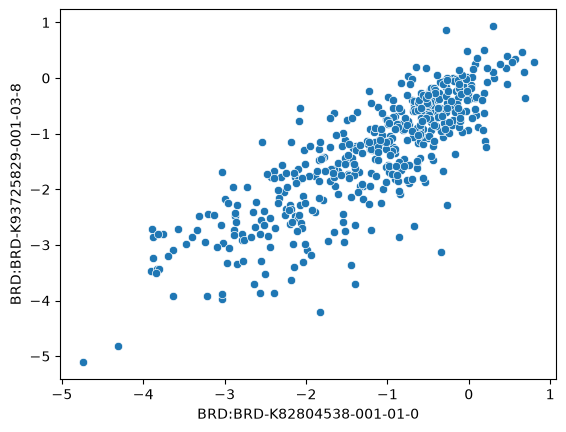

In [19]:
drug_A = corr_matrix_tofilter_descending.iat[100,0]
drug_B = corr_matrix_tofilter_descending.iat[100,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
5351,REP.1M,2.5,NaN,BROMODOMAIN INHIBITOR,BRD:BRD-K00003108-001-01-9,ABBV-744,ABBV-744
5992,REP.1M,2.5,NaN,BROMODOMAIN INHIBITOR,BRD:BRD-K00005242-001-01-9,TEN-010,TEN-010


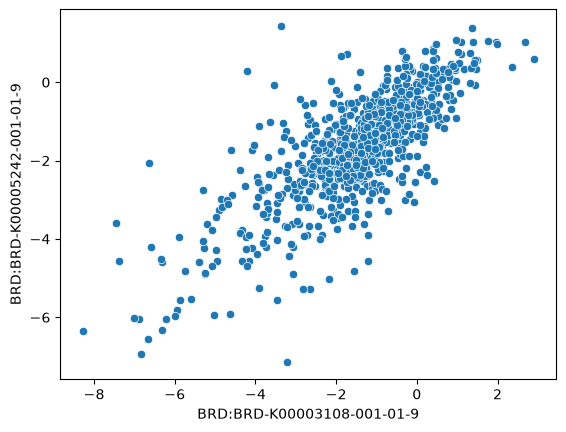

In [20]:
drug_A = corr_matrix_tofilter_descending.iat[300,0]
drug_B = corr_matrix_tofilter_descending.iat[300,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
6704,REP.300,2.5,NaN,NaN,BRD:BRD-K00091075-001-01-9,E-7386,E-7386
6729,REP.300,2.5,NaN,NaN,BRD:BRD-K00091108-001-01-9,PRI-724,PRI-724


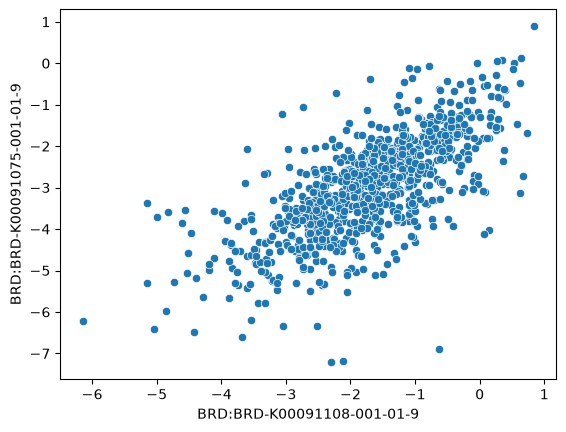

In [21]:
drug_A = corr_matrix_tofilter_descending.iat[1000,0]
drug_B = corr_matrix_tofilter_descending.iat[1000,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

This drug pair have no annotated targets in this metadata, but a quick Google search reveals them both to be inhibitors of the Wnt/Beta-catenin pathway. This is a good example of the drug metadata being useful but not complete (just because a drug doesn't have an annotated target here doesn't mean that its target is unknown...)

,screen,dose,repurposing_target,MOA,IDs,Drug.Name,Synonyms
3956,REP.PRIMARY,2.5,CTNNB1,BETA-CATENIN INHIBITOR,BRD:BRD-K94455792-001-01-8,ICG-001,ICG-001
6729,REP.300,2.5,NaN,NaN,BRD:BRD-K00091108-001-01-9,PRI-724,PRI-724


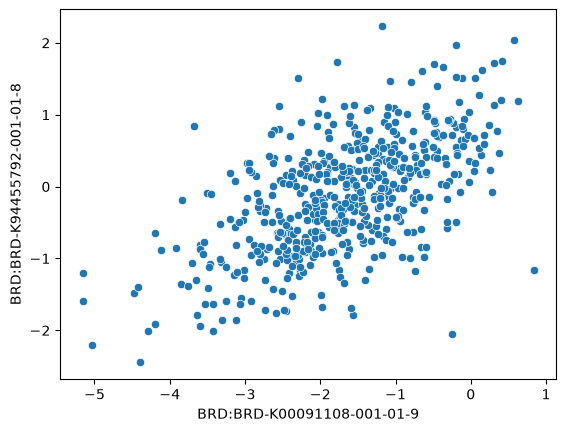

In [22]:
drug_A = corr_matrix_tofilter_descending.iat[5000,0]
drug_B = corr_matrix_tofilter_descending.iat[5000,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
drug_metadata_subset.head()

           screen  dose repurposing_target                       MOA  \
1221  REP.PRIMARY   2.5                NaN  RNA POLYMERASE INHIBITOR   
3460  REP.PRIMARY   2.5                NaN             DNA INHIBITOR   

                             IDs    Drug.Name     Synonyms  
1221  BRD:BRD-K12787259-001-04-3      CX-5461      CX-5461  
3460  BRD:BRD-K78960041-001-03-2  OXALIPLATIN  OXALIPLATIN  
                                Drug                     Partner   Pearson
39303080  BRD:BRD-K12787259-001-04-3  BRD:BRD-K78960041-001-03-2  0.415408


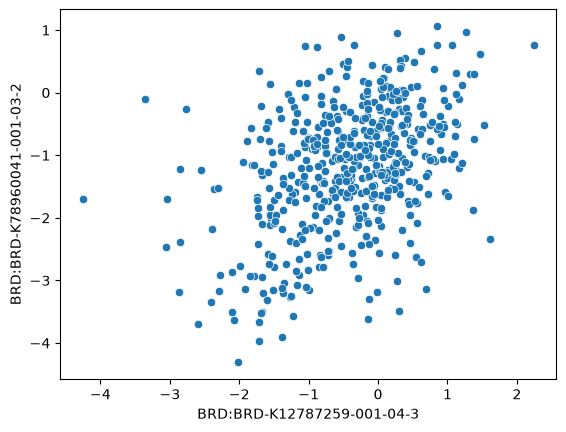

In [23]:
row = 50000

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)

           screen  dose repurposing_target  \
4908  REP.PRIMARY   2.5        TP53, USP14   
4994  REP.PRIMARY   2.5              HIF1A   

                                                    MOA  \
4908  ANTITUMOR AGENT, UBIQUITIN C-TERMINAL HYDROLAS...   
4994                 HYPOXIA INDUCIBLE FACTOR ACTIVATOR   

                             IDs Drug.Name         Synonyms  
4908  BRD:BRD-K26122255-001-01-7    VLX600  VLX-600, VLX600  
4994  BRD:BRD-K44432556-001-05-5     ML228    ML-228, ML228  
                                Drug                     Partner   Pearson
21820344  BRD:BRD-K44432556-001-05-5  BRD:BRD-K26122255-001-01-7  0.892588


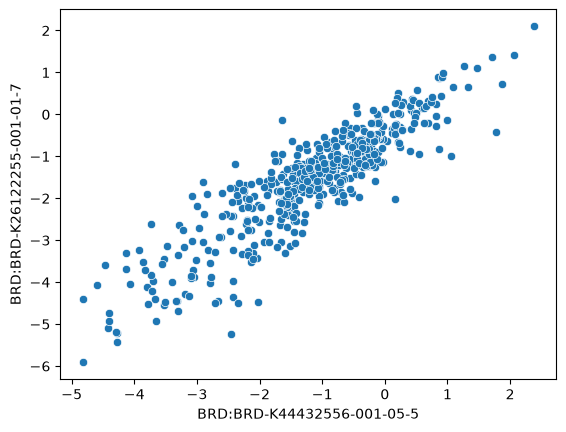

In [24]:
#got a bit smarter about setting the row (but not much...)

row = 8

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)

This is a really neat example: while these drugs would appear to have to different annotated targets, a closer look reveals that they both act via similar mechanisms (both are iron chelators, meaning that they sponge up iron inside the cell, which is important for mitochondrial metabolism among other things). So, even though VLX600 is annotated as a 'antitumor agent, UPS inhibitor' and ML228 is annotated as a 'HIF activator', these are both just iron chelators with likely overlapping functions inside of cells (evidenced by their clear functional correlation!)

           screen  dose repurposing_target            MOA  \
1692  REP.PRIMARY   2.5             MAP2K1  MEK INHIBITOR   
2047  REP.PRIMARY   2.5             MAP3K1  MEK INHIBITOR   

                             IDs Drug.Name Synonyms  
1692  BRD:BRD-K26667523-001-02-5   TAK-733  TAK-733  
2047  BRD:BRD-K37687095-001-06-9   AZD8330  AZD8330  
                                Drug                     Partner   Pearson
22044104  BRD:BRD-K37687095-001-06-9  BRD:BRD-K26667523-001-02-5  0.867977


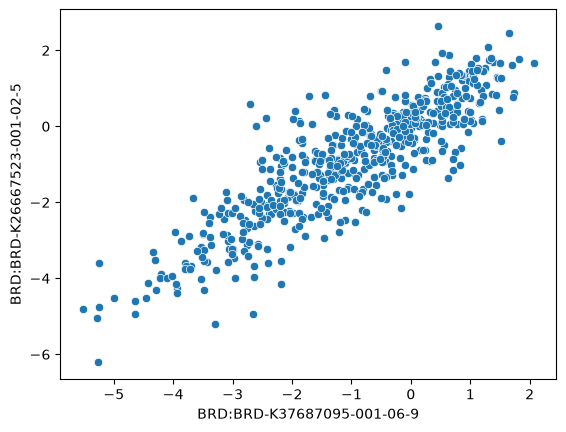

In [25]:
row = 31

drug_A = corr_matrix_tofilter_descending.iat[row,0]
drug_B = corr_matrix_tofilter_descending.iat[row,1]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

corr_matrix_tofilter_descending_subset = corr_matrix_tofilter_descending.iloc[[row]]
print(corr_matrix_tofilter_descending_subset)

** Benchmark Drug Sets 7-14-2026 **

Now, let's try to construct some benchmark drug sets- groups of drugs with known mechanisms of action (MOAs)- to use to benchmark our correlation/network/clustering analyses. To start, I queried the PRISM drug metadata and pulled out several sets of drugs with a single shared target (for this analysis, I limited the sets to contain only drugs with a single, shared target between them). These sets differ in the target and in their size (i.e. number of drugs in each set) to hopefully include a pretty diverse set of drugs. 

Read in the data, subset the correlation matrix to include only these drugs, and plot a heatmap of the results: 

<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

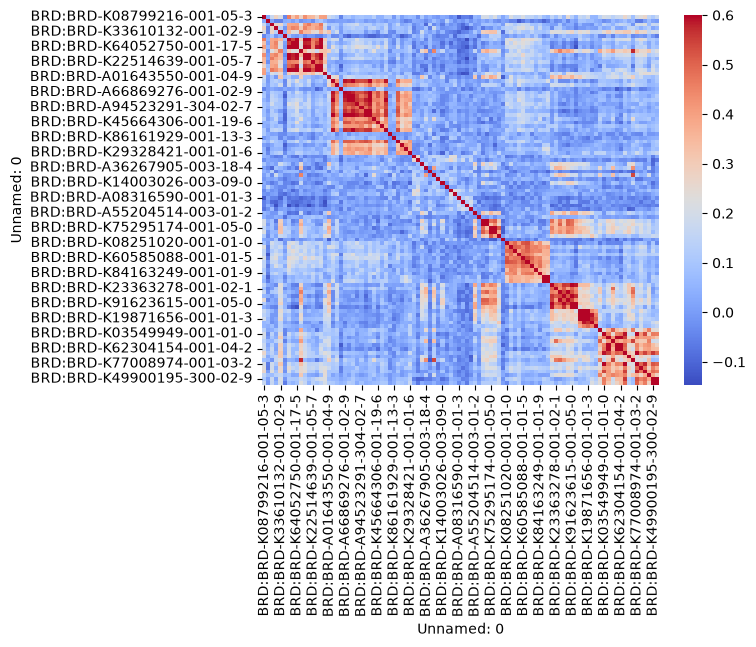

In [131]:
BenchmarkSets = pd.read_csv('PRISM_BenchmarkSets.csv')
BenchmarkDrugs = BenchmarkSets['Drug_ID']

corr_matrix_Benchmark = corr_matrix_full.loc[BenchmarkDrugs, BenchmarkDrugs]

sea.heatmap(corr_matrix_Benchmark, annot=False, cmap='coolwarm', vmax=0.6)

This is mega cool, because now we can see little 'neighborhoods' or 'clusters' of drugs which correlate strongly with each other- I'd bet money that these correspond pretty well to the different benchmark drug sets (8 benchmark sets - 8 of these neighborhoods). Note the different scale on the heatmap. 

For each of the benchmark sets, I'd like to examine the distribution of Pearson correlation coefficients 'in the set' (i.e. among the members of the benchmark set) compared to the distribution of Pearson correlation coefficients in the entire dataset (which we plotted above). This isn't difficult to do, but write a function to facilitate doing this analysis to other drug sets in the future: 

In [159]:
def CorrelationDistribution (CorrelationMatrixLong, ListOfBenchmarkSets, BenchmarkOfInterest, ax=None) :

    if ax is None: 
        ax = plt.gca()    

    AllCorrelations = CorrelationMatrixLong['Pearson']

    BenchmarkDrugIDs = ListOfBenchmarkSets.loc[ListOfBenchmarkSets['Benchmark_Description']==BenchmarkOfInterest, 'Drug_ID']

    BenchmarkCorrelations = CorrelationMatrixLong.loc[CorrelationMatrixLong['Drug'].isin(BenchmarkDrugIDs) & CorrelationMatrixLong['Partner'].isin(BenchmarkDrugIDs), 'Pearson']

    colors = ['skyblue', 'salmon']
    
    ax.hist([AllCorrelations, BenchmarkCorrelations], label=['Whole dataset', BenchmarkOfInterest], color=colors, bins=15, density=True)

    return ax
    

Now, call this function to plot the correlation distributions for each of the eight benchmark sets (I know there is a cleaner way to iterate through a vector of these, but hopefully this manual approach will do for now):

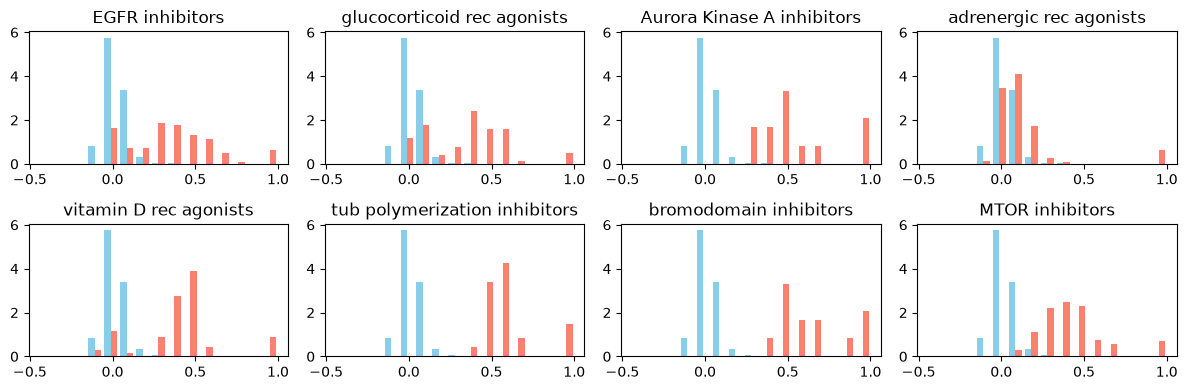

In [157]:

fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize=(12,4))

CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'EGFR inhibitors', ax=ax[0,0])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'glucocorticoid receptor agonists', ax=ax[0,1])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'Aurora Kinase A inhibitors', ax=ax[0,2])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'adrenergic receptor agonists', ax=ax[0,3])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'vitamin D receptor agonists', ax=ax[1,0])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'tubulin polymerization inhibitors', ax=ax[1,1])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'bromodomain inhibitors', ax=ax[1,2])
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'MTOR inhibitors', ax=ax[1,3])

ax[0,0].set_title('EGFR inhibitors')
ax[0,1].set_title('glucocorticoid rec agonists')
ax[0,2].set_title('Aurora Kinase A inhibitors')
ax[0,3].set_title('adrenergic rec agonists')
ax[1,0].set_title('vitamin D rec agonists')
ax[1,1].set_title('tub polymerization inhibitors')
ax[1,2].set_title('bromodomain inhibitors')
ax[1,3].set_title('MTOR inhibitors')

plt.tight_layout()
plt.show()


Neat- looks like in every case, the dsn of Pearson coefficients is shifted to the right in the benchmark sets (what we expect, if correlations really do indicate functional drug relationships). But there definitely seem to be some benchmark sets containing very low correlations (presumably, from under-dosed drugs or drugs which otherwise showed weak effects in the screen). Adrenergic receptor agonists seems to be an outlier in the shift of correlation distributions, let's take a closer look at just this set: 

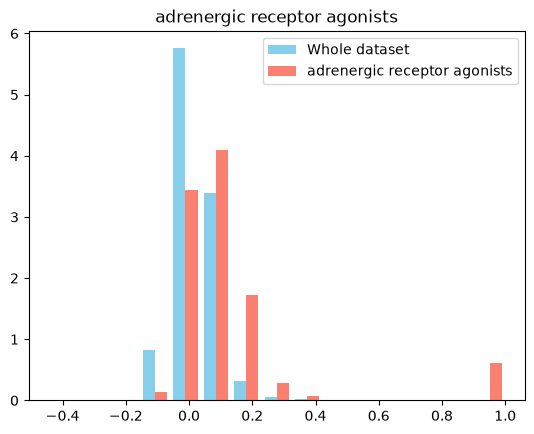

In [162]:
CorrelationDistribution(corr_matrix_tofilter_long, BenchmarkSets, 'adrenergic receptor agonists')
plt.title('adrenergic receptor agonists')
plt.legend()

Looks like the majority of drugs do not correlate well, with maybe one or two exceptions. Is this because these drugs show very small/absent effects in the screen to begin with? 

To get at this question, subset the initial drug screen dataset to these drugs and plot as a heatmap: 

<Axes: xlabel='Unnamed: 0'>

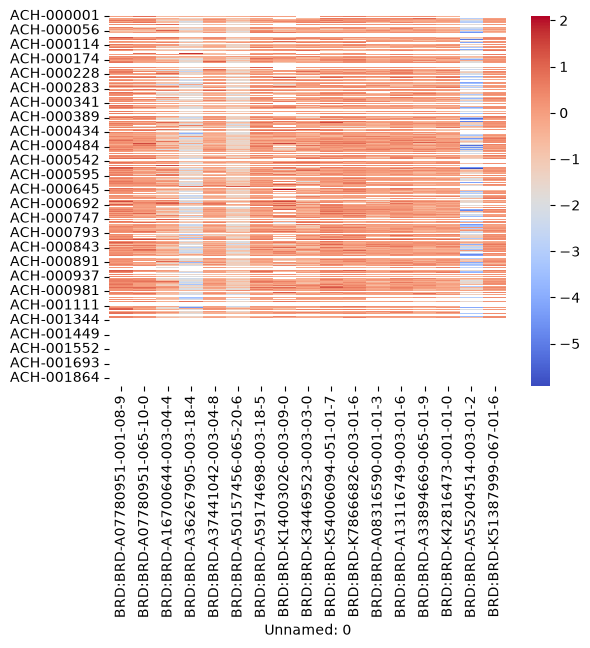

In [165]:
adrenergicDrugIDs = BenchmarkSets.loc[BenchmarkSets['Benchmark_Description'] == 'adrenergic receptor agonists', 'Drug_ID']

screenDataAdrenergic = screenData[adrenergicDrugIDs]

sea.heatmap(screenDataAdrenergic, annot=False, cmap='coolwarm')

It sure does seem like the drug effects aren't really there for most of the drugs in most of the cell lines (and if anything, are actually positive?). Another way to visualize this is to plot the median drug effect for each drug across all cell lines: 

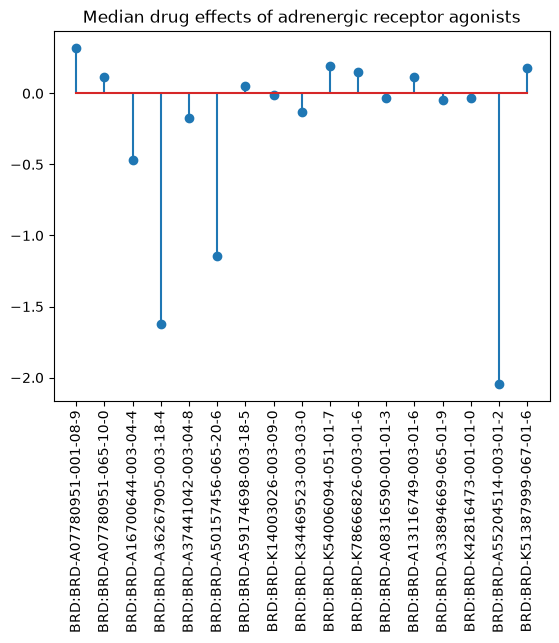

In [172]:
medians = screenDataAdrenergic.median(numeric_only=True)
x= medians.keys()

plt.stem(x,medians)
plt.xticks(rotation='vertical')
plt.title('Median drug effects of adrenergic receptor agonists')
plt.show()

Indeed, most of these drugs don't do much! Do the three drugs which do have an effect correlate with each other? Let's check one pair first: 

           screen  dose repurposing_target                          MOA                         IDs   Drug.Name  \
339   REP.PRIMARY   2.5              ADRB2  ADRENERGIC RECEPTOR AGONIST  BRD:BRD-A36267905-003-18-4   BUPHENINE   
4732  REP.PRIMARY   2.5              ADRB2  ADRENERGIC RECEPTOR AGONIST  BRD:BRD-A55204514-003-01-2  HIGENAMINE   

        Synonyms  
339    BUPHENINE  
4732  HIGENAMINE  


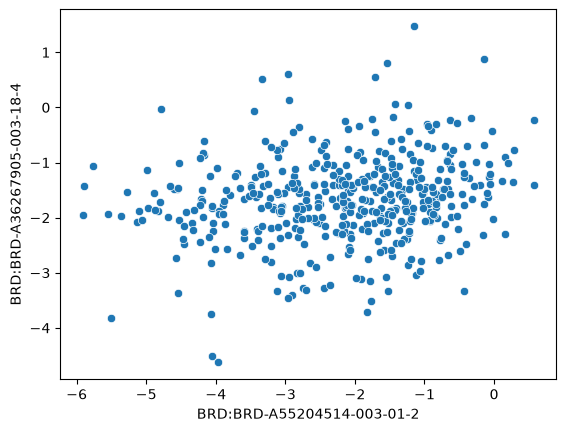

In [ ]:
drug_A = medians.keys()[15]
drug_B = medians.keys()[3]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

Eh, not really. How about every combination of the three drugs with effects below -0.5?

<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

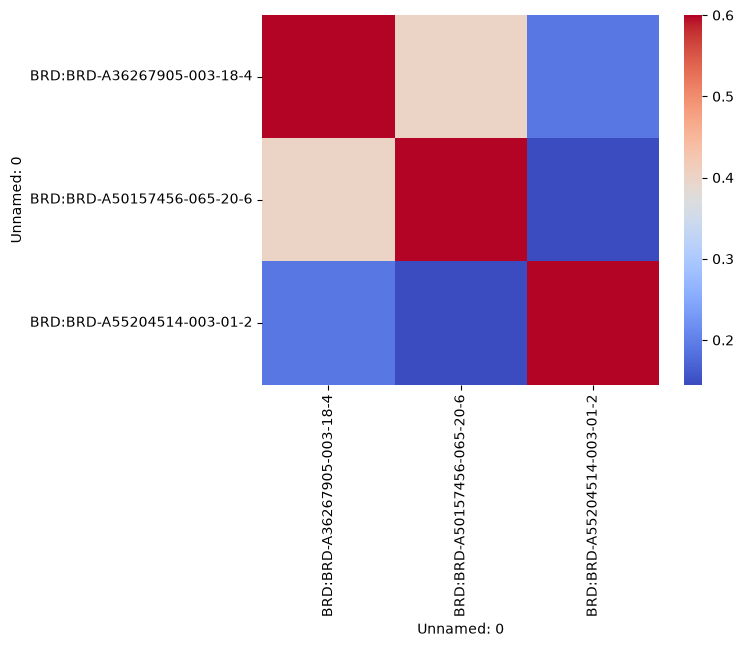

In [181]:
drug_A = medians.keys()[3]
drug_B = medians.keys()[5]
drug_C = medians.keys()[15]

drugs = [drug_A, drug_B, drug_C]

corr_matrix_threedrugs = corr_matrix_full.loc[drugs, drugs]

sea.heatmap(corr_matrix_threedrugs, annot=False, cmap='coolwarm', vmax=0.6)

Looks like two of them do, the rest don't! These are the two that do: 

          screen  dose repurposing_target                          MOA                         IDs    Drug.Name  \
339  REP.PRIMARY   2.5              ADRB2  ADRENERGIC RECEPTOR AGONIST  BRD:BRD-A36267905-003-18-4    BUPHENINE   
452  REP.PRIMARY   2.5              ADRB2  ADRENERGIC RECEPTOR AGONIST  BRD:BRD-A50157456-065-20-6  TERBUTALINE   

        Synonyms  
339    BUPHENINE  
452  TERBUTALINE  


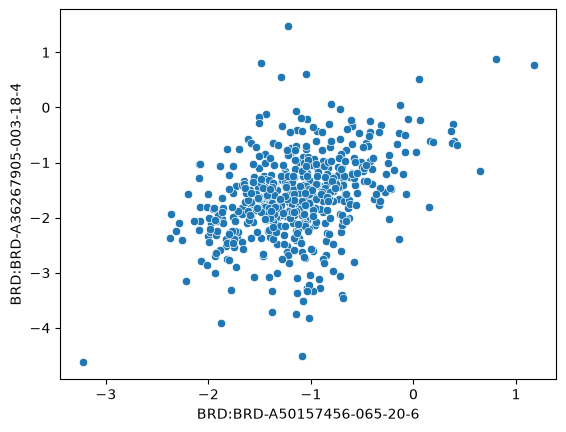

In [182]:
drug_A = medians.keys()[5]
drug_B = medians.keys()[3]

temp_data = screenData[[drug_A, drug_B]]
temp_data = temp_data.dropna()

sea.scatterplot(data=temp_data, x=temp_data.iloc[:, 0], y=temp_data.iloc[:, 1])

drug_metadata_subset = drugMetadata[drugMetadata['IDs'].isin([drug_A,drug_B])]
print(drug_metadata_subset)

So, the takeaway is: this benchmark set may not be ideal since most drugs in it do not show effects; but, of the drugs that do show effects, we can still detect correlation in accordance with their shared target! 

Now, let's do the following: for a given drug in this group of EGFR inhibitors, I want to plot the correlations between this drug and every other drug in the EGFR inhibitor benchmark set (n=41 drugs), as well as the correlation between this drug and 41 randomly-chosen drugs from the entire PRISM dataset: 

In [ ]:
#for now, identify the drug of interest using its index in the EGFR inhibitor dataframe

drug_of_interest = EGFR_Inhibitor_IDs[2]

#subset the long correlation matrix to only those correlations including the drug of interest

corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]

#subset this to get correlations between the drug of interest and the other annotated EGFR inhibitors 

corrs_EGFR = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(EGFR_Inhibitor_IDs)]

#now, subset to find the correlations between the drug of interest and 41 randomly-selected drugs in the dataset 

corrs_random = corrs_drugofinterest.sample(n=41)

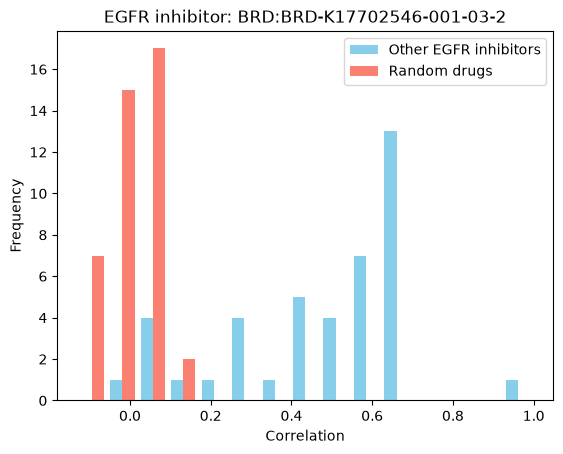

In [54]:
#plot both sets of correlations on a histogram

colors = ['skyblue', 'salmon']
plt.hist([corrs_EGFR['Pearson'], corrs_random['Pearson']], label=['Other EGFR inhibitors', 'Random drugs'], color=colors, bins=15)
plt.title(f'EGFR inhibitor: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

This looks great. Let's try with another one of the EGFR inhibitors: 

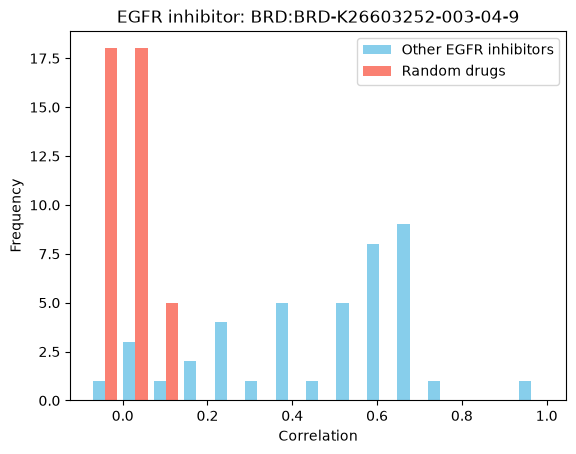

In [55]:
drug_of_interest = EGFR_Inhibitor_IDs[5]
corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]
corrs_EGFR = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(EGFR_Inhibitor_IDs)]
corrs_random = corrs_drugofinterest.sample(n=41)

colors = ['skyblue', 'salmon']
plt.hist([corrs_EGFR['Pearson'], corrs_random['Pearson']], label=['Other EGFR inhibitors', 'Random drugs'], color=colors, bins=15)
plt.title(f'EGFR inhibitor: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

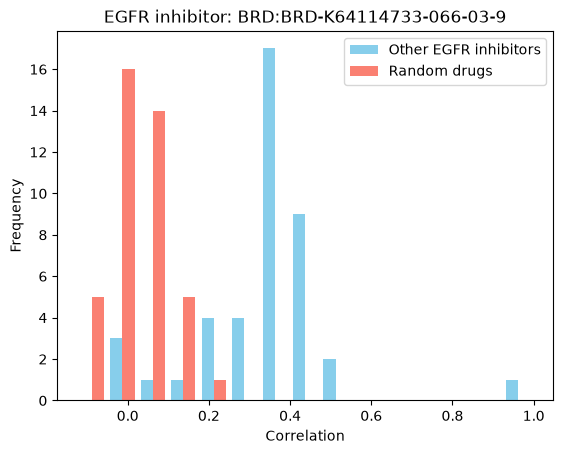

In [60]:
drug_of_interest = EGFR_Inhibitor_IDs[40]
corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]
corrs_EGFR = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(EGFR_Inhibitor_IDs)]
corrs_random = corrs_drugofinterest.sample(n=41)

colors = ['skyblue', 'salmon']
plt.hist([corrs_EGFR['Pearson'], corrs_random['Pearson']], label=['Other EGFR inhibitors', 'Random drugs'], color=colors, bins=15)
plt.title(f'EGFR inhibitor: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

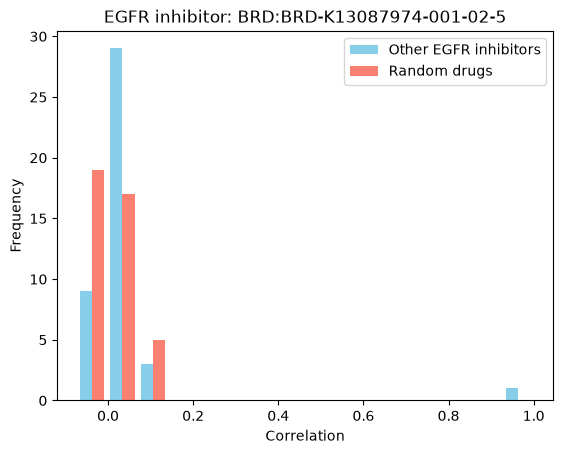

In [62]:
drug_of_interest = EGFR_Inhibitor_IDs[1]
corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]
corrs_EGFR = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(EGFR_Inhibitor_IDs)]
corrs_random = corrs_drugofinterest.sample(n=41)

colors = ['skyblue', 'salmon']
plt.hist([corrs_EGFR['Pearson'], corrs_random['Pearson']], label=['Other EGFR inhibitors', 'Random drugs'], color=colors, bins=15)
plt.title(f'EGFR inhibitor: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

This is an interesting example of an annotated EGFR inhibitor that does not correlate any better with other EGFR inhibitors than with random drugs. To see why, let's examine the overall drug effect data for this drug: 

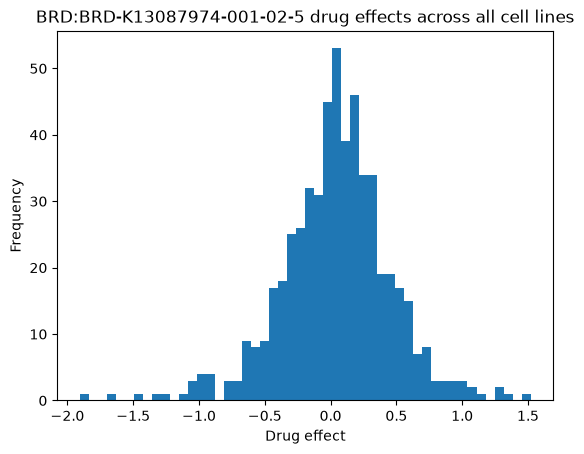

In [69]:
drug_of_interest = EGFR_Inhibitor_IDs[1]

drug_of_interest_data = screenData[drug_of_interest]

plt.hist(drug_of_interest_data, bins=50)
plt.title(f'{drug_of_interest} drug effects across all cell lines')
plt.xlabel('Drug effect')
plt.ylabel('Frequency')
plt.yscale('linear')

So, it looks like this drug does not affect the majority of cell lines in the entire screen. It was screened at 2.5uM, and it's difficult to find papers using this drug, but I found one (https://link.springer.com/article/10.1186/s12967-025-06455-w) that doesn't see effects until ~5-10uM.... 

So, it seems likely that the reason this drug doesn't correlate well with other EGFR inhibitors is that it was dosed too low and so there are no effects to correlate in the first place! 

Let's contrast this result with one of the other EGFR inhibitors that does show correlations: 

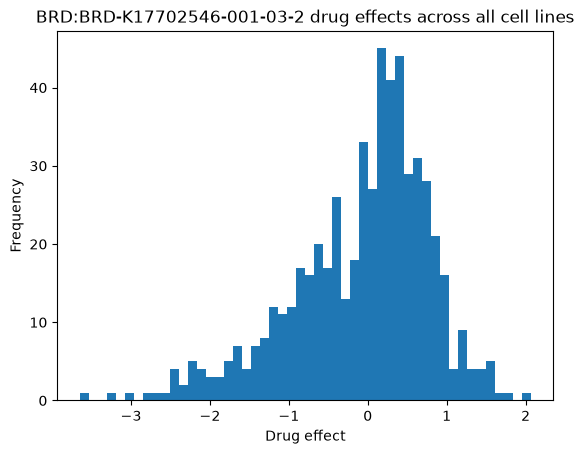

In [70]:
drug_of_interest = EGFR_Inhibitor_IDs[2]

drug_of_interest_data = screenData[drug_of_interest]

plt.hist(drug_of_interest_data, bins=50)
plt.title(f'{drug_of_interest} drug effects across all cell lines')
plt.xlabel('Drug effect')
plt.ylabel('Frequency')
plt.yscale('linear')

Here are the drug effects of another EGFR inhibitor from the correlation heatmap that correlated poorly with other EGFR inhibitors: 

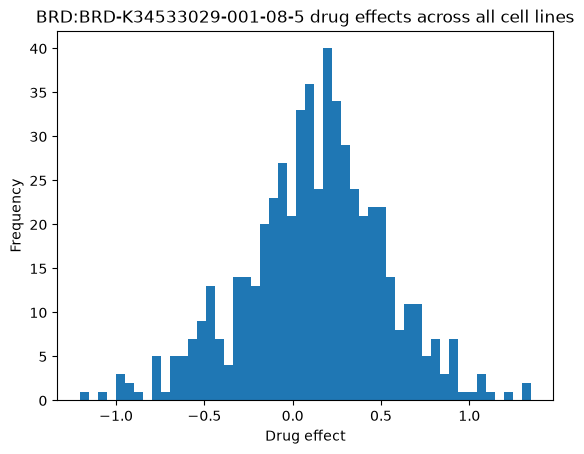

In [71]:
drug_of_interest = EGFR_Inhibitor_IDs[9]

drug_of_interest_data = screenData[drug_of_interest]

plt.hist(drug_of_interest_data, bins=50)
plt.title(f'{drug_of_interest} drug effects across all cell lines')
plt.xlabel('Drug effect')
plt.ylabel('Frequency')
plt.yscale('linear')

** Network Analysis Pilot Run **

Going to try using a combination of NetworkX (for network/graph construction, manipulation, and analysis) and Pyvis (for interactive visualization) to make some networks using the correlation matrices. 

In [77]:
#import new libraries 

import networkx as nx
from pyvis.network import Network

In [90]:
#start with the correlation matrix for the EGFR inhibitors so that dataset is small and more manageable and make a graph where edge weights are correlation coefficients

G = nx.from_pandas_adjacency(corr_matrix_EGFR)

#remove 'self loops' i.e. drug X connecting to itself

G.remove_edges_from(nx.selfloop_edges(G))

#visualize this network using pyvis

EGFR_network = Network(notebook=True, cdn_resources='in_line')
EGFR_network.from_nx(G)
EGFR_network.show("ex.html")

with open("ex.html", "r", encoding="utf-8") as f:
    html_content = f.read()

display(HTML(html_content))

ex.html


NameError: name 'HTML' is not defined

<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

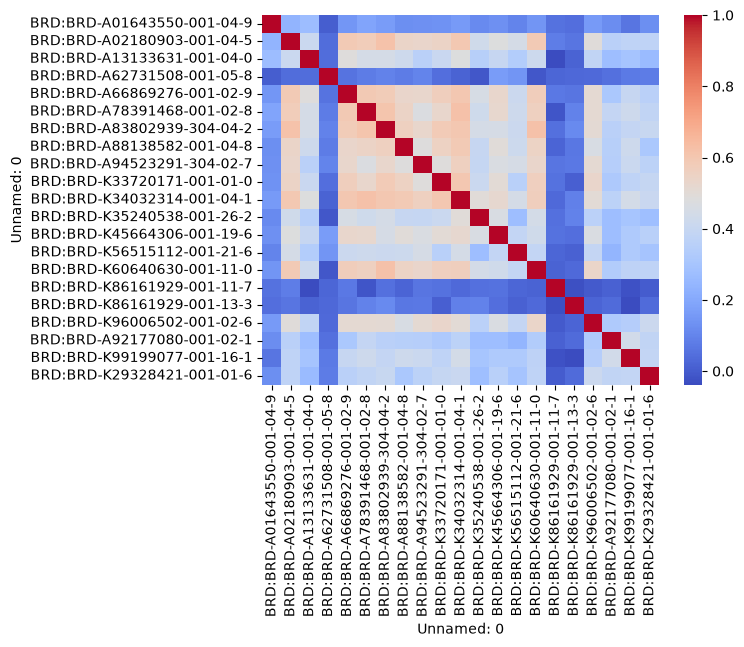

In [96]:
BenchmarkSets = pd.read_csv('PRISM_BenchMarkSets.csv')
Benchmark_GlucoCort = BenchmarkSets.loc[BenchmarkSets['Group']=='GLUCOCORTICOID RECEPTOR AGONIST']
GlucoCort_Inhibitor_IDs = Benchmark_GlucoCort['DrugID']

corr_matrix_GlucoCort = corr_matrix_full.loc[GlucoCort_Inhibitor_IDs, GlucoCort_Inhibitor_IDs]

sea.heatmap(corr_matrix_GlucoCort, annot=False, cmap='coolwarm')

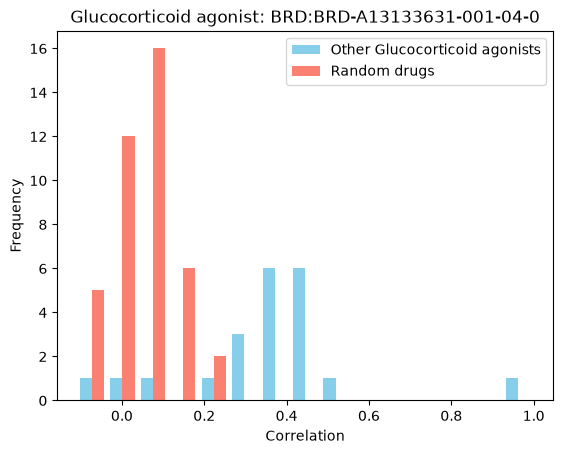

In [99]:
GlucoCort_Inhibitor_IDs = GlucoCort_Inhibitor_IDs.reset_index(drop=True)
drug_of_interest = GlucoCort_Inhibitor_IDs[2]
corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]
corrs_GlucoCort = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(GlucoCort_Inhibitor_IDs)]
corrs_random = corrs_drugofinterest.sample(n=41)

colors = ['skyblue', 'salmon']
plt.hist([corrs_GlucoCort['Pearson'], corrs_random['Pearson']], label=['Other Glucocorticoid agonists', 'Random drugs'], color=colors, bins=15)
plt.title(f'Glucocorticoid agonist: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

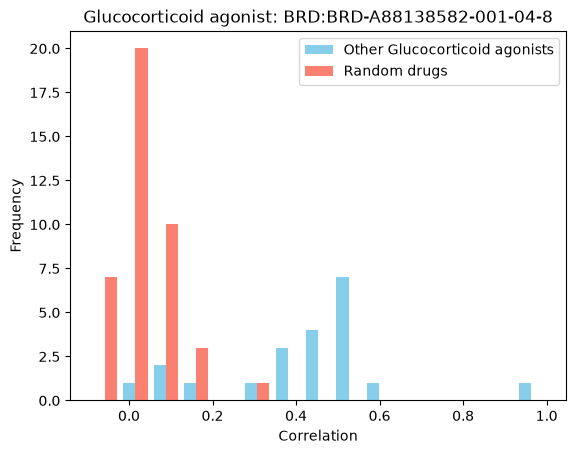

In [102]:
GlucoCort_Inhibitor_IDs = GlucoCort_Inhibitor_IDs.reset_index(drop=True)
drug_of_interest = GlucoCort_Inhibitor_IDs[7]
corrs_drugofinterest = corr_matrix_tofilter_long.loc[corr_matrix_tofilter_long['Drug'] == drug_of_interest]
corrs_GlucoCort = corrs_drugofinterest.loc[corrs_drugofinterest['Partner'].isin(GlucoCort_Inhibitor_IDs)]
corrs_random = corrs_drugofinterest.sample(n=41)

colors = ['skyblue', 'salmon']
plt.hist([corrs_GlucoCort['Pearson'], corrs_random['Pearson']], label=['Other Glucocorticoid agonists', 'Random drugs'], color=colors, bins=15)
plt.title(f'Glucocorticoid agonist: {drug_of_interest}')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('linear')

In [ ]:
corr_mat_subset = corr_matrix_full.loc[100]

KeyError: 100